In [2]:
import pandas as pd
from kg_analytics import *
from IPython.display import display

prime_kg_df = pd.read_csv("primekg/kg.csv", low_memory=False)

In [ ]:
features_df = pd.read_csv('primekg/disease_features.csv')
features_df.head()

,node_index,mondo_id,mondo_name,group_id_bert,group_name_bert,mondo_definition,umls_description,orphanet_definition,orphanet_prevalence,orphanet_epidemiology,orphanet_clinical_description,orphanet_management_and_treatment,mayo_symptoms,mayo_causes,mayo_risk_factors,mayo_complications,mayo_prevention,mayo_see_doc
0,27165,8019,mullerian aplasia and hyperandrogenism,NaN,NaN,"Deficiency of the glycoprotein WNT4, associate...","Deficiency of the glycoprotein wnt4, associate...","A rare syndrome with 46,XX disorder of sex dev...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,27165,8019,mullerian aplasia and hyperandrogenism,NaN,NaN,"Deficiency of the glycoprotein WNT4, associate...","Deficiency of the glycoprotein wnt4, associate...","A rare syndrome with 46,XX disorder of sex dev...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,27166,11043,"myelodysplasia, immunodeficiency, facial dysmo...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,27168,8878,"bone dysplasia, lethal Holmgren type",NaN,NaN,Bone dysplasia lethal Holmgren type (BDLH) is ...,A lethal bone dysplasia with characteristics o...,Bone dysplasia lethal Holmgren type (BDLH) is ...,<1/1000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,27169,8905,predisposition to invasive fungal disease due ...,NaN,NaN,NaN,NaN,"A rare, genetic primary immunodeficiency chara...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
from pykeen.datasets import get_dataset

dataset = get_dataset(dataset="primekg")

In [15]:
dataset.training

TriplesFactory(num_entities=129262, num_relations=30, create_inverse_triples=False, num_triples=6479992, path="C:\Users\wittd\.data\pykeen\datasets\primekg\primekg.csv")

In [ ]:
dataset.testing.mapped_triples

tensor([[ 57550,     12,   8032],
        [ 56661,      2,  80366],
        [ 44888,     10,  75639],
        ...,
        [ 39189,     29,  50552],
        [127710,      2,  34250],
        [ 41430,     12,  45205]])

: 

In [8]:
# aha tehát a name a key a pykeenben!
# hmmm érdekes
all_nodes = extract_all_nodes(prime_kg_df)
all_nodes_index = all_nodes.drop_duplicates(subset=["index"]).reset_index(drop=True)
all_nodes_name = all_nodes.drop_duplicates(subset=["name"]).reset_index(drop=True)

all_nodes.shape, all_nodes_index.shape, all_nodes_name.shape

((16200996, 5), (129375, 5), (129262, 5))

In [15]:
dup_names = all_nodes_index[all_nodes_index.duplicated(subset=["name"])].reset_index(drop=True)

In [22]:
name_to_idx_n = all_nodes.groupby("name", dropna=False)["index"].nunique(dropna=False).rename("index_per_name")
name_conflicts = name_to_idx_n[name_to_idx_n > 1].reset_index()
display(name_conflicts)
display(name_conflicts["index_per_name"].value_counts())

,name,index_per_name
0,4-hydroxyphenylacetic aciduria,2
1,Acetaminophen,2
2,Ammonia,2
3,Amoxicillin,2
4,Androstenedione,2
...,...,...
107,parallel fiber,2
108,rRNA processing,2
109,synostosis,2
110,tRNA processing,2


index_per_name
2    111
3      1
Name: count, dtype: int64

In [28]:
from pykeen.triples.triples_factory import TriplesFactory

def load_primekg_triples_factory(csv_path: str) -> TriplesFactory:
    """
    Betölt egy PrimeKG kg.csv fájlt és TriplesFactory-vá alakítja.
    
    A CSV többek között ezeket az oszlopokat tartalmazza:
    x_index, x_id, x_type, x_name, y_index, y_id, y_type, y_name, 
    relation, display_relation, ...
    
    Ebből csak az szükséges a tanításhoz:
    - x_index (head entitás ID)
    - display_relation (reláció)
    - y_index (tail entitás ID)
    """
    kg_df = pd.read_csv(csv_path, low_memory=False)
    
    # Ezek az oszlopok a PrimeKG-ben mindig ott vannak
    triples_df = kg_df[["x_index", "relation", "y_index"]].copy()
    triples_df.columns = ["head", "relation", "tail"]
    
    # Tisztítás
    triples_df = triples_df.dropna()
    triples_df["head"] = triples_df["head"].astype(str)
    triples_df["relation"] = triples_df["relation"].astype(str)
    triples_df["tail"] = triples_df["tail"].astype(str)
    
    # TriplesFactory létrehozás
    labeled_triples = triples_df[["head", "relation", "tail"]].to_numpy(dtype=str)
    return TriplesFactory.from_labeled_triples(triples=labeled_triples)


In [29]:
tf = load_primekg_triples_factory("primekg/kg.csv")

In [30]:
tf

TriplesFactory(num_entities=129375, num_relations=30, create_inverse_triples=False, num_triples=8100128)

In [27]:
tf
# miért van csak 18 relation 30 helyett? mert nincs minden relationhöz disply rel!

TriplesFactory(num_entities=129375, num_relations=18, create_inverse_triples=False, num_triples=8100498)

In [ ]:
prime_kg_df.head()

,relation,display_relation,x_index,x_id,x_type,x_name,x_source,y_index,y_id,y_type,y_name,y_source
0,protein_protein,ppi,0,9796,gene/protein,PHYHIP,NCBI,8889,56992,gene/protein,KIF15,NCBI
1,protein_protein,ppi,1,7918,gene/protein,GPANK1,NCBI,2798,9240,gene/protein,PNMA1,NCBI
2,protein_protein,ppi,2,8233,gene/protein,ZRSR2,NCBI,5646,23548,gene/protein,TTC33,NCBI
3,protein_protein,ppi,3,4899,gene/protein,NRF1,NCBI,11592,11253,gene/protein,MAN1B1,NCBI
4,protein_protein,ppi,4,5297,gene/protein,PI4KA,NCBI,2122,8601,gene/protein,RGS20,NCBI


In [13]:
inspect_key_consistency(prime_kg_df)

,column,rows,nulls,nunique,duplicates
0,index,16200996,0,129375,16071621
1,id,16200996,0,90067,16110929
2,type,16200996,0,10,16200986
3,name,16200996,0,129262,16071734
4,source,16200996,0,9,16200987


,id,index_per_id
0,1,4
1,10,4
2,100,4
3,1000,5
4,10000,4
...,...,...
21627,9995,5
21628,9996,3
21629,9997,4
21630,9998,3


,name,index_per_name
0,4-hydroxyphenylacetic aciduria,2
1,Acetaminophen,2
2,Ammonia,2
3,Amoxicillin,2
4,Androstenedione,2
...,...,...
107,parallel fiber,2
108,rRNA processing,2
109,synostosis,2
110,tRNA processing,2


In [ ]:
prime_kg_df = filter_df(prime_kg_df, filter_type="nodes", types=["disease", "gene/protein"])

In [2]:
compute_degrees(prime_kg_df)

,node_id,node_type,out_degree,in_degree,total_degree
0,0,gene/protein,131,131,262
1,1,gene/protein,212,212,424
2,2,gene/protein,196,196,392
3,3,gene/protein,637,637,1274
4,4,gene/protein,262,262,524
...,...,...,...,...,...
129370,129370,pathway,58,58,116
129371,129371,pathway,30,30,60
129372,129372,anatomy,4,4,8
129373,129373,anatomy,17355,17355,34710


In [3]:
reverse_edge_consistency_check(prime_kg_df)

['both']
Categories (3, str): ['left_only', 'right_only', 'both']


In [4]:
calc_global_stats(prime_kg_df)

{'total_nodes': 129375,
 'total_edges': 8100498,
 'num_node_types': 10,
 'num_edge_types': 30,
 'node_types': ['anatomy',
  'biological_process',
  'cellular_component',
  'disease',
  'drug',
  'effect/phenotype',
  'exposure',
  'gene/protein',
  'molecular_function',
  'pathway'],
 'edge_types': ['anatomy_anatomy',
  'anatomy_protein_absent',
  'anatomy_protein_present',
  'bioprocess_bioprocess',
  'bioprocess_protein',
  'cellcomp_cellcomp',
  'cellcomp_protein',
  'contraindication',
  'disease_disease',
  'disease_phenotype_negative',
  'disease_phenotype_positive',
  'disease_protein',
  'drug_drug',
  'drug_effect',
  'drug_protein',
  'exposure_bioprocess',
  'exposure_cellcomp',
  'exposure_disease',
  'exposure_exposure',
  'exposure_molfunc',
  'exposure_protein',
  'indication',
  'molfunc_molfunc',
  'molfunc_protein',
  'off-label use',
  'pathway_pathway',
  'pathway_protein',
  'phenotype_phenotype',
  'phenotype_protein',
  'protein_protein'],
 'density': 0.000483965

In [6]:
connected_components_summary(prime_kg_df)

{'num_components': 1,
 'largest_component_size': 129375,
 'smallest_component_size': 129375,
 'component_sizes': [129375],
 'isolated_node_count': 0}

In [7]:
node_type_stats(prime_kg_df)

,node_type,node_count,mean_degree,median_degree,std_degree,min_degree,max_degree,p90_degree,p99_degree,isolated_nodes
0,biological_process,28642,17.610642,8.0,56.365663,2,3312,32.0,182.00,0
1,gene/protein,27671,190.179538,142.0,213.370458,2,11160,412.0,848.60,0
2,disease,17080,39.958314,12.0,99.283282,2,3048,96.0,386.00,0
3,effect/phenotype,15311,33.583175,6.0,136.054573,2,4798,52.0,551.80,0
4,anatomy,14035,223.178340,2.0,2326.460891,2,34710,6.0,552.56,0
5,molecular_function,11169,17.319903,4.0,254.823517,2,25092,20.4,210.00,0
6,drug,7957,705.214528,26.0,1039.257026,2,5200,2370.0,3904.00,0
7,cellular_component,4176,44.589080,4.0,394.398994,2,10814,37.0,611.50,0
8,pathway,2516,37.930048,18.0,59.801911,2,958,98.0,260.00,0
9,exposure,818,22.826406,8.0,55.044784,2,682,52.0,243.28,0


In [8]:
relation_type_stats(prime_kg_df)

,relation,src_type,dst_type,edge_count,relation_density,unique_heads,unique_tails,avg_tails_per_head,avg_heads_per_tail,relation_class
0,drug_drug,drug,drug,2672628,0.146035,4278,4278,624.737728,624.737728,N-N
1,anatomy_protein_present,gene/protein,anatomy,1518203,0.379791,24829,161,61.146361,9429.832298,N-N
2,anatomy_protein_present,anatomy,gene/protein,1518203,0.379791,161,24829,9429.832298,61.146361,N-N
3,protein_protein,gene/protein,gene/protein,642150,0.001906,18354,18354,34.986924,34.986924,N-N
4,disease_phenotype_positive,effect/phenotype,disease,150317,0.002370,9404,6744,15.984368,22.288998,N-N
5,disease_phenotype_positive,disease,effect/phenotype,150317,0.002370,6744,9404,22.288998,15.984368,N-N
6,bioprocess_protein,gene/protein,biological_process,144805,0.000623,18650,12459,7.764343,11.622522,N-N
7,bioprocess_protein,biological_process,gene/protein,144805,0.000623,12459,18650,11.622522,7.764343,N-N
8,bioprocess_bioprocess,biological_process,biological_process,105772,0.000129,28642,28642,3.692899,3.692899,N-N
9,cellcomp_protein,cellular_component,gene/protein,83402,0.002453,1756,19363,47.495444,4.307287,N-N


In [9]:
mx = connectivity_matrix(prime_kg_df)

In [10]:
schema_edge_type_counts(prime_kg_df)

,x_type,y_type,edge_count,num_relations,relations
0,drug,drug,2672628,1,drug_drug
1,anatomy,gene/protein,1538090,2,"anatomy_protein_absent, anatomy_protein_present"
2,gene/protein,anatomy,1538090,2,"anatomy_protein_absent, anatomy_protein_present"
3,gene/protein,gene/protein,642150,1,protein_protein
4,disease,effect/phenotype,151510,2,"disease_phenotype_negative, disease_phenotype_..."
5,effect/phenotype,disease,151510,2,"disease_phenotype_negative, disease_phenotype_..."
6,gene/protein,biological_process,144805,1,bioprocess_protein
7,biological_process,gene/protein,144805,1,bioprocess_protein
8,biological_process,biological_process,105772,1,bioprocess_bioprocess
9,cellular_component,gene/protein,83402,1,cellcomp_protein


In [11]:
target_relation_analysis(prime_kg_df) # todo fejleszteni

,x_index,y_index,relation,x_type,y_type
5949716,28313,7097,disease_protein,disease,gene/protein
5949717,28313,2174,disease_protein,disease,gene/protein
5949718,28313,8038,disease_protein,disease,gene/protein
5949719,28313,5925,disease_protein,disease,gene/protein
5949720,28313,238,disease_protein,disease,gene/protein


{'src_type': 'disease',
 'dst_type': 'gene/protein',
 'relation': None,
 'total_edges': 80411,
 'unique_src': 5593,
 'unique_dst': 9080,
 'cold_start_src_lte2': 2935,
 'cold_start_src_zero': 11487,
 'top_src_hubs': [(32617, 1156),
  (28347, 1085),
  (35771, 1074),
  (84243, 1074),
  (84244, 1074),
  (36691, 1074),
  (28313, 890),
  (28849, 819),
  (36480, 702),
  (36538, 702),
  (30826, 662),
  (35963, 616),
  (35966, 616),
  (29646, 614),
  (36634, 612),
  (31116, 556),
  (37334, 538),
  (36999, 521),
  (37115, 521),
  (83870, 521)],
 'top_dst_hubs': [(4959, 273),
  (1785, 257),
  (177, 247),
  (2329, 225),
  (1567, 208),
  (2621, 200),
  (125, 183),
  (4425, 174),
  (1980, 171),
  (769, 157),
  (6175, 157),
  (2927, 154),
  (7817, 151),
  (1641, 149),
  (236, 142),
  (361, 140),
  (2429, 137),
  (1004, 136),
  (749, 136),
  (729, 135)]}

In [12]:
metapath_schema_analysis(prime_kg_df)

,metapath_types,relation_sequence,hop_length
0,disease -> gene/protein,disease_protein,1
1,disease -> disease -> gene/protein,disease_disease -> disease_protein,2
2,disease -> drug -> gene/protein,contraindication -> drug_protein,2
3,disease -> drug -> gene/protein,indication -> drug_protein,2
4,disease -> drug -> gene/protein,off-label use -> drug_protein,2
...,...,...,...
59,disease -> gene/protein -> effect/phenotype ->...,disease_protein -> phenotype_protein -> phenot...,3
60,disease -> gene/protein -> exposure -> gene/pr...,disease_protein -> exposure_protein -> exposur...,3
61,disease -> gene/protein -> gene/protein -> gen...,disease_protein -> protein_protein -> protein_...,3
62,disease -> gene/protein -> molecular_function ...,disease_protein -> molfunc_protein -> molfunc_...,3


In [2]:
# Standalone KG analytics workflow (dataset builder untouched)
kg_df = pd.read_csv('primekg/kg.csv', low_memory=False)
features_df = pd.read_csv('primekg/disease_features.csv')

triples_df = normalize_kg_dataframe(kg_df)
analyzer = KGAnalyzer(triples_df)

global_report = analyzer.global_stats()
relation_df = analyzer.relation_stats()
degree_df = analyzer.degree_stats()
component_stats = analyzer.connected_components()
power_law = analyzer.power_law_summary()

print('Global report:', global_report)
print('Power-law summary:', power_law)
relation_df.head(10)

Global report: {'total_nodes': 90067, 'total_edges': 8100498, 'unique_relations': 18, 'density': 0.000998585249237365, 'self_loops': 112, 'duplicate_triples': 3318, 'head_types': 10, 'tail_types': 10}
Power-law summary: {'exponent': 1.1146687692309187, 'r_squared': 0.7326872370985591}


,relation,edge_count,unique_heads,unique_tails,avg_tails_per_head,avg_heads_per_tail,cardinality
0,expression present,3036406,24891,24891,121.988108,121.988108,N-to-N
1,synergistic interaction,2672628,4278,4278,624.737728,624.737728,N-to-N
2,interacts with,686550,38118,38118,18.011176,18.011176,N-to-N
3,ppi,642150,18354,18354,34.986924,34.986924,N-to-N
4,phenotype present,300634,14329,14329,20.980808,20.980808,N-to-N
5,parent-child,281744,63487,63487,4.437822,4.437822,N-to-N
6,associated with,167482,13916,13916,12.035211,12.035211,N-to-N
7,side effect,129568,2127,2127,60.915844,60.915844,N-to-N
8,contraindication,61350,2458,2458,24.959317,24.959317,N-to-N
9,expression absent,39774,7219,7219,5.509627,5.509627,N-to-N


In [3]:
# Type-aware outputs (uses x_type / y_type when present in kg.csv)
if {'head_type', 'tail_type'}.issubset(triples_df.columns):
    connectivity_df = analyzer.connectivity_matrix()
    display(connectivity_df)
else:
    connectivity_df = None
    print('No type columns found after normalization.')

target_rel = relation_df.iloc[0]['relation']
target_report = analyzer.target_relation_analysis(target_rel)
print('Target relation:', target_rel)
print(target_report)

metapath_df = (
    analyzer.metapath_analysis_sampled(
        src_type='disease',
        dst_type='gene/protein',
        max_hops=3,
        random_seed=42,
    )
    if {'head_type', 'tail_type'}.issubset(triples_df.columns)
    else pd.DataFrame()
)
metapath_df.head(20)

tail_type,anatomy,biological_process,cellular_component,disease,drug,effect/phenotype,exposure,gene/protein,molecular_function,pathway
head_type,,,,,,,,,,
anatomy,28064,0,0,0,0,0,0,1538090,0,0
biological_process,0,105772,0,0,0,0,1625,144805,0,0
cellular_component,0,0,9690,0,0,0,10,83402,0,0
disease,0,0,0,64388,42631,151510,2304,80411,0,0
drug,0,0,0,42631,2672628,64784,0,25653,0,0
effect/phenotype,0,0,0,151510,64784,37472,0,3330,0,0
exposure,0,1625,10,2304,0,0,4140,1212,45,0
gene/protein,1538090,144805,83402,80411,25653,3330,1212,642150,69530,42646
molecular_function,0,0,0,0,0,0,45,69530,27148,0


Target relation: expression present
{'relation': 'expression present', 'edges': 3036406, 'unique_heads': 24891, 'unique_tails': 24891, 'head_degree_mean': 121.98810815154071, 'tail_degree_mean': 121.98810815154071, 'top_heads': {'468': 17408, '2108': 16989, '473': 16880, '3889': 16746, '160': 16642, '2367': 16618, '2106': 16598, '1043': 16585, '945': 16525, '9834': 16512, '2046': 16480, '82': 16417, '1155': 16277, '2369': 16204, '1044': 16073, '1296': 16004, '1225': 15963, '451': 15956, '1870': 15924, '992': 15841}, 'top_tails': {'468': 17408, '2108': 16989, '473': 16880, '3889': 16746, '160': 16642, '2367': 16618, '2106': 16598, '1043': 16585, '945': 16525, '9834': 16512, '2046': 16480, '82': 16417, '1155': 16277, '2369': 16204, '1044': 16073, '1296': 16004, '1225': 15963, '451': 15956, '1870': 15924, '992': 15841}}


,path,length,count
0,disease[associated with]gene/protein,1,1
1,disease[phenotype absent]effect/phenotype -> e...,2,1
2,disease[phenotype present]effect/phenotype -> ...,2,1
3,disease[parent-child]disease -> disease[associ...,2,1
4,disease[contraindication]drug -> drug[carrier]...,2,1
5,disease[contraindication]drug -> drug[enzyme]g...,2,1
6,disease[contraindication]drug -> drug[target]g...,2,1
7,disease[contraindication]drug -> drug[transpor...,2,1
8,disease[indication]drug -> drug[carrier]gene/p...,2,1
9,disease[indication]drug -> drug[enzyme]gene/pr...,2,1


,relation,edge_count,unique_pairs,reverse_hits,symmetry_ratio
0,expression present,3036406,3033804,3033804,1.0
1,synergistic interaction,2672628,2672628,2672628,1.0
2,interacts with,686550,686422,686422,1.0
3,ppi,642150,642150,642150,1.0
4,phenotype present,300634,300629,300629,1.0
5,parent-child,281744,281170,281170,1.0
6,associated with,167482,167473,167473,1.0
7,side effect,129568,129568,129568,1.0
8,contraindication,61350,61350,61350,1.0
9,expression absent,39774,39774,39774,1.0


tail_type,anatomy,biological_process,cellular_component,disease,drug,effect/phenotype,exposure,gene/protein,molecular_function,pathway
head_type,,,,,,,,,,
anatomy,28064.0,0.0,0.0,0.0,0.0,0.0,0.0,1538090.0,0.0,0.0
biological_process,0.0,105772.0,0.0,0.0,0.0,0.0,1625.0,144805.0,0.0,0.0
cellular_component,0.0,0.0,9690.0,0.0,0.0,0.0,10.0,83402.0,0.0,0.0
disease,0.0,0.0,0.0,64388.0,42631.0,151510.0,2304.0,80411.0,0.0,0.0
drug,0.0,0.0,0.0,42631.0,2672628.0,64784.0,0.0,25653.0,0.0,0.0
effect/phenotype,0.0,0.0,0.0,151510.0,64784.0,37472.0,0.0,3330.0,0.0,0.0
exposure,0.0,1625.0,10.0,2304.0,0.0,0.0,4140.0,1212.0,45.0,0.0
gene/protein,1538090.0,144805.0,83402.0,80411.0,25653.0,3330.0,1212.0,642150.0,69530.0,42646.0
molecular_function,0.0,0.0,0.0,0.0,0.0,0.0,45.0,69530.0,27148.0,0.0


tail_type,anatomy,biological_process,cellular_component,disease,drug,effect/phenotype,exposure,gene/protein,molecular_function,pathway
head_type,,,,,,,,,,
anatomy,0.018,0.000,0.000,0.000,0.000,0.000,0.000,0.982,0.000,0.000
biological_process,0.000,0.419,0.000,0.000,0.000,0.000,0.006,0.574,0.000,0.000
cellular_component,0.000,0.000,0.104,0.000,0.000,0.000,0.000,0.896,0.000,0.000
disease,0.000,0.000,0.000,0.189,0.125,0.444,0.007,0.236,0.000,0.000
drug,0.000,0.000,0.000,0.015,0.953,0.023,0.000,0.009,0.000,0.000
effect/phenotype,0.000,0.000,0.000,0.589,0.252,0.146,0.000,0.013,0.000,0.000
exposure,0.000,0.174,0.001,0.247,0.000,0.000,0.443,0.130,0.005,0.000
gene/protein,0.585,0.055,0.032,0.031,0.010,0.001,0.000,0.244,0.026,0.016
molecular_function,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.719,0.281,0.000


,head_type,tail_type,edge_count,unique_relations,relations
0,drug,drug,2672628,1,[synergistic interaction]
1,anatomy,gene/protein,1538090,2,"[expression absent, expression present]"
2,gene/protein,anatomy,1538090,2,"[expression absent, expression present]"
3,gene/protein,gene/protein,642150,1,[ppi]
4,effect/phenotype,disease,151510,2,"[phenotype absent, phenotype present]"
5,disease,effect/phenotype,151510,2,"[phenotype absent, phenotype present]"
6,biological_process,gene/protein,144805,1,[interacts with]
7,gene/protein,biological_process,144805,1,[interacts with]
8,biological_process,biological_process,105772,1,[parent-child]
9,cellular_component,gene/protein,83402,1,[interacts with]


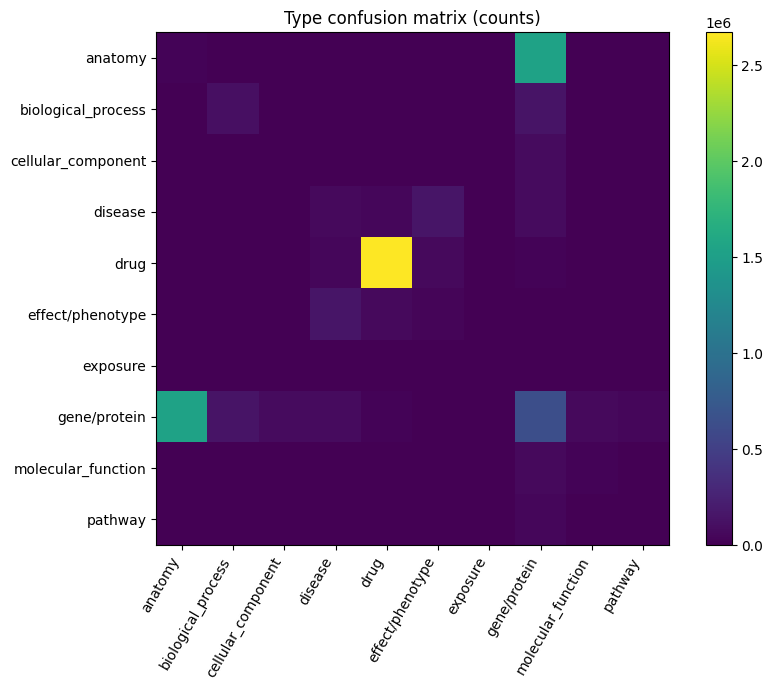

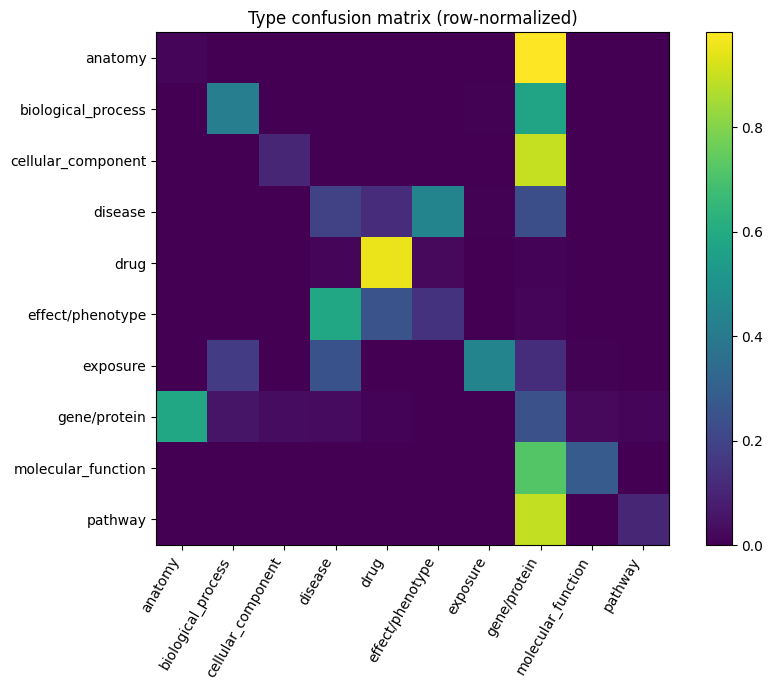

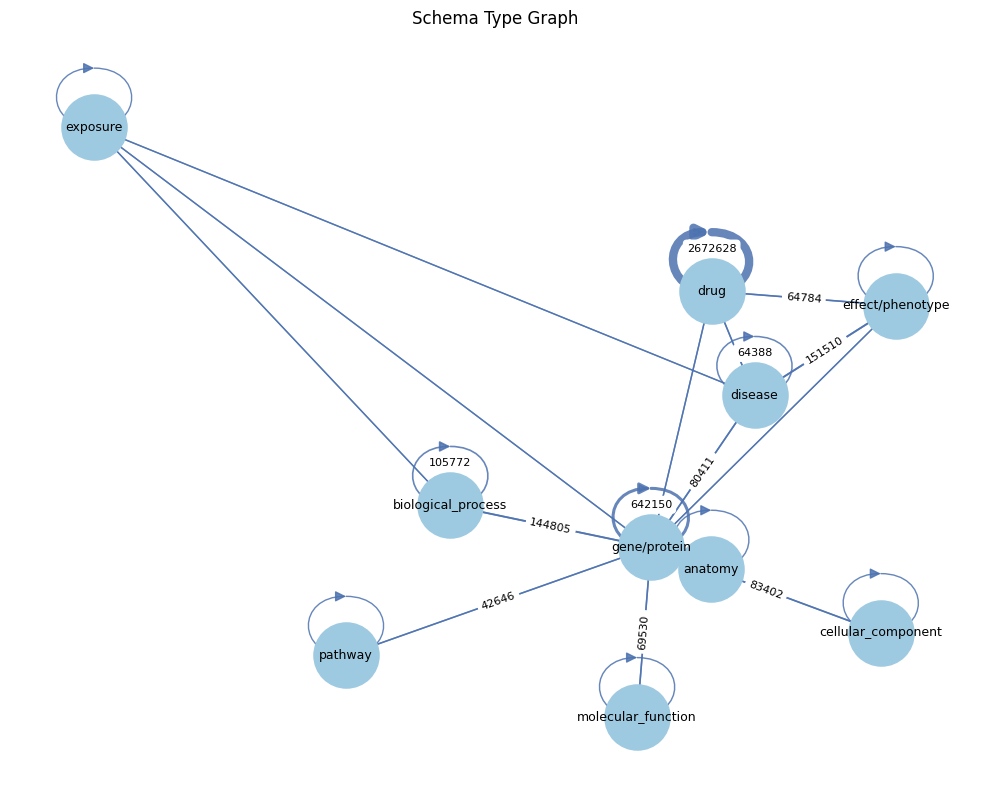

In [ ]:
# Symmetry + confusion-matrix style views + schema graph
symmetry_df = analyzer.relation_symmetry_stats(min_edges=100)
display(symmetry_df.head(20))

if {'head_type', 'tail_type'}.issubset(triples_df.columns):
    conf_counts = analyzer.type_confusion_matrix(normalize=False)
    conf_probs = analyzer.type_confusion_matrix(normalize=True)
    schema_edges = analyzer.schema_edge_type_counts()

    display(conf_counts)
    display(conf_probs.round(3))
    display(schema_edges.head(20))

    plot_type_confusion_heatmap(conf_counts, title='Type confusion matrix (counts)')
    plot_type_confusion_heatmap(conf_probs, title='Type confusion matrix (row-normalized)')
    plot_schema_type_graph(schema_edges, min_edge_count=1000)
else:
    print('Type columns are missing, so confusion matrix and schema graph are not available.')

# mit jelent hogy nem unique minden pár?

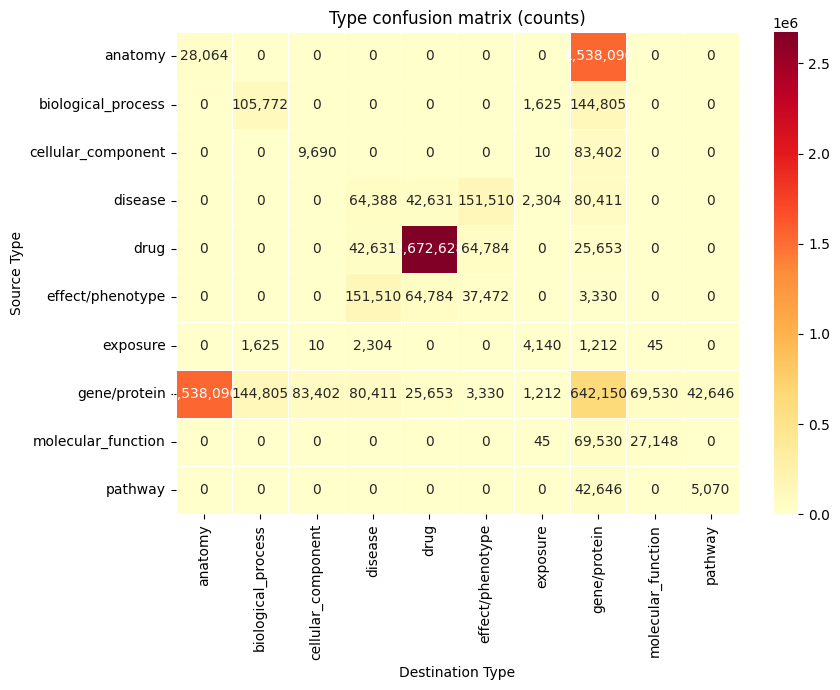

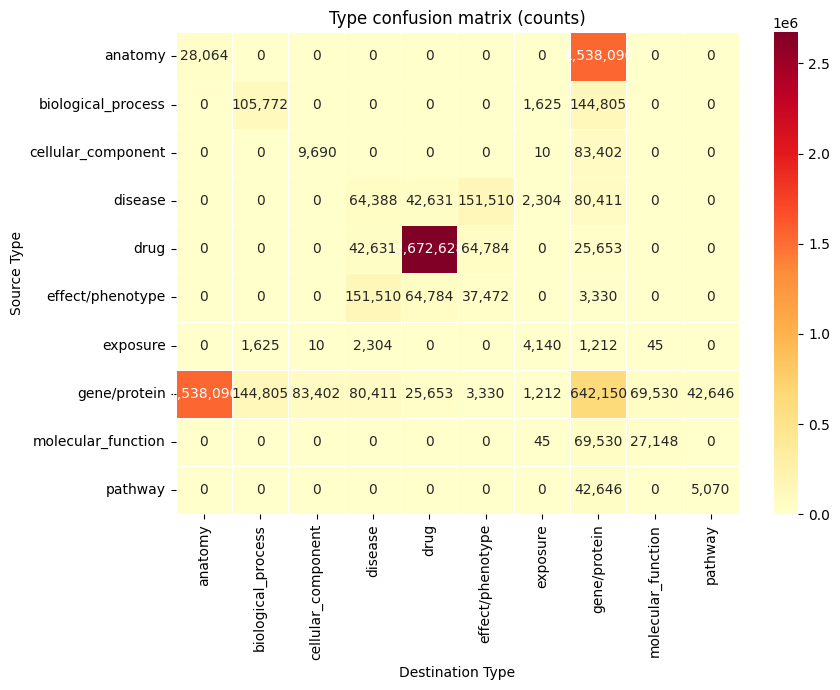

In [6]:
conf_counts = analyzer.type_confusion_matrix(normalize=False)
plot_type_confusion_heatmap(conf_counts, title='Type confusion matrix (counts)')


In [4]:
# Feature readiness: how well external features can be joined to graph entities
feature_readiness = analyzer.feature_readiness_report(
    features_df,
    feature_key_col='node_index',
)
feature_readiness

{'graph_entities': 90067,
 'feature_entities': 17080,
 'joinable_entities': 7959,
 'coverage_ratio': 0.08836754860270687,
 'missing_feature_entities': 82108,
 'orphan_feature_rows': 9121,
 'coverage_by_type': [{'entity_type': 'biological_process',
   'entities': 24820,
   'joinable': 2766,
   'coverage_ratio': 0.11144238517324738},
  {'entity_type': 'gene/protein',
   'entities': 18481,
   'joinable': 976,
   'coverage_ratio': 0.05281099507602403},
  {'entity_type': 'molecular_function',
   'entities': 10260,
   'joinable': 1142,
   'coverage_ratio': 0.11130604288499026},
  {'entity_type': 'drug',
   'entities': 7957,
   'joinable': 0,
   'coverage_ratio': 0.0},
  {'entity_type': 'disease',
   'entities': 7457,
   'joinable': 83,
   'coverage_ratio': 0.011130481426847258},
  {'entity_type': 'effect/phenotype',
   'entities': 7349,
   'joinable': 1433,
   'coverage_ratio': 0.19499251598856987},
  {'entity_type': 'anatomy',
   'entities': 6605,
   'joinable': 372,
   'coverage_ratio': 0.

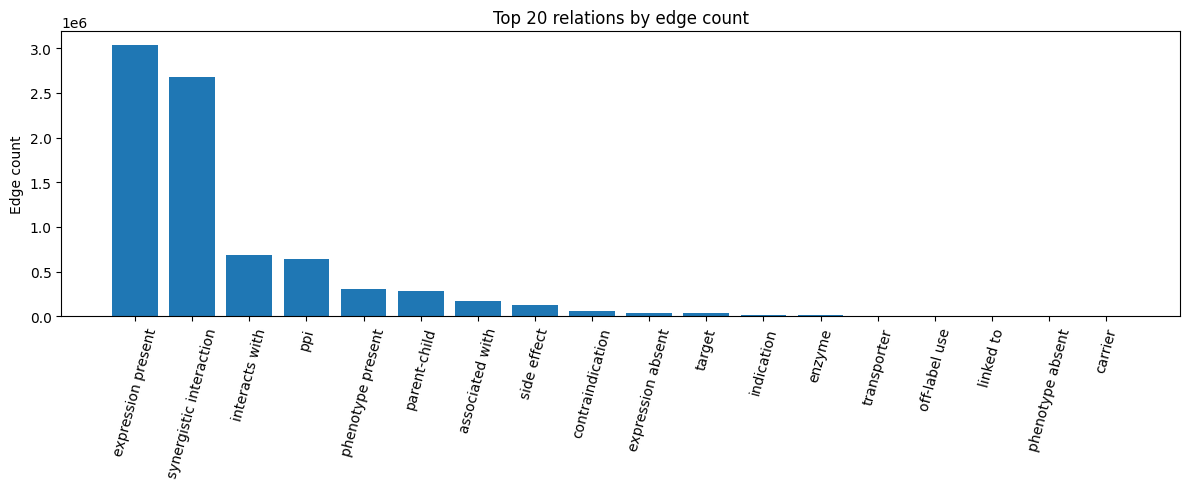

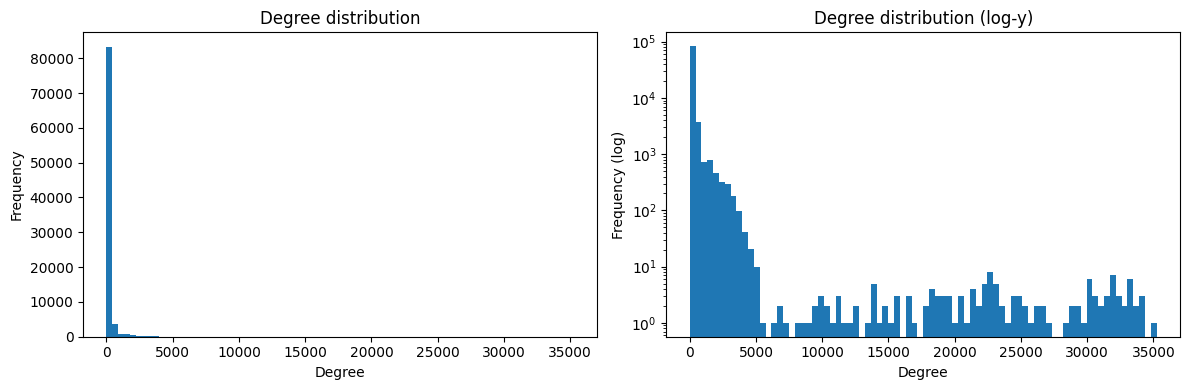

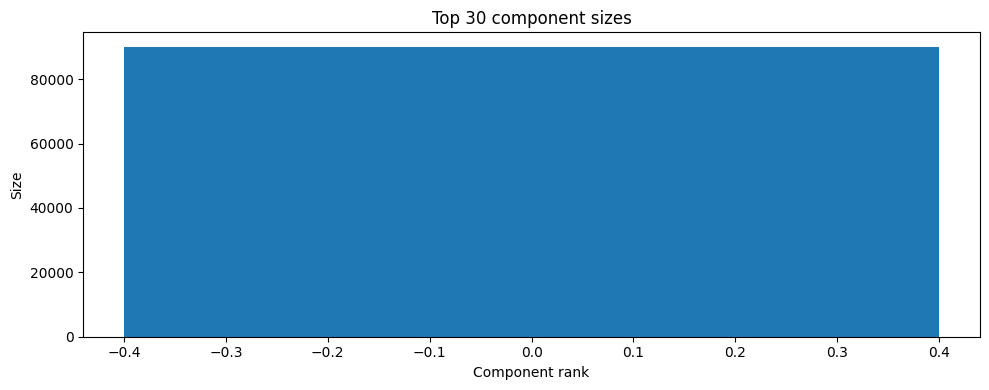

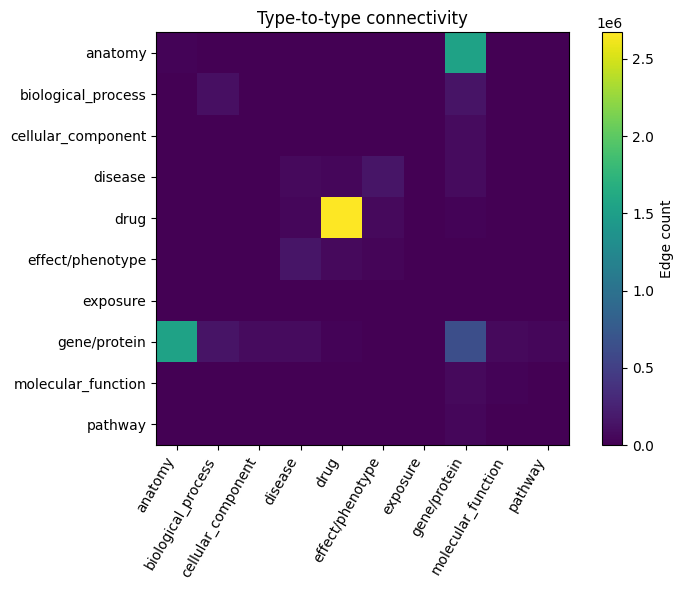

In [5]:
# Plots
plot_relation_distribution(relation_df, top_n=20)
plot_degree_distribution(degree_df)
plot_component_sizes(component_stats, top_n=30)
if connectivity_df is not None:
    plot_connectivity_heatmap(connectivity_df)